# INFO 648: Final Project.
Nikole Hairston and Jacob Teeter \

Predicting 2030 Neighborhood Growth: Mountain Region


# Phase 1: Business Understanding

Problem statement: The U.S. Department of Economic Development sends federal funding to the states and wants the money to follow where people are moving. We are trying to predict which neighborhoods are gaining population, find out what is driving growth, and forecast it through 2030 so the USDED can target funding by state.

Who cares and why: The USDED plans budgets years in advance for schools, roads, and housing. If we can flag growth neighborhoods early, they can build capacity before people arrive instead of after.

Target definition and cutoff.
- growth_pct = ((pop_2020 - pop_2010) / pop_2010) * 100

Then we make a yes/no target called growth:
- growth = 1 if growth_pct >= 10

- Decrease or stays same = 0, if <10

If a population increases by 10% or more over the upcoming decade then the tract is categorized as a growth tract.

The assignment's recommended rule is growth_pct > 0, but that labels a tract that gained a handful of people as "grew," which is a weak bar. We decided to use 10% so the positive class is identifiable significant growth. We report the resulting class balance in Phase 3.

Success criterion:
- We need to test the AUC above the default .50 threshold to ensure feasability of the predictive model.
- Test accuracy above the majority class rate.   

# Phase 2: Data Understanding

Assigned division: Mountain

States: Arizona, Colorado, Idaho, Montana, Nevada, New Mexico, Utah, and Wyoming.

Tract Count: 5,250

Columns we will use:

- pct_owner
- pct_vacant
- pct_kids
- pct_seniors
- pct_white
- pct_black
- pct_hisp
- density_perkm2
- settlement_type
- STATE

In [15]:

import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("/content/student_tracts_raw (1).csv")
df.head()

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
0,G0100010020100,Alabama,1,Autauga County,1,20100,1912,693,59,536,...,21,0,1,0,13,9,1775.0,9.809944,194.904273,suburban
1,G0100010020200,Alabama,1,Autauga County,1,20200,2170,743,79,469,...,44,3,0,0,24,4,2055.0,3.340505,649.602380,suburban
2,G0100010020300,Alabama,1,Autauga County,1,20300,3373,1256,70,949,...,38,0,2,0,28,19,3216.0,5.349274,630.552856,suburban
3,G0100010020400,Alabama,1,Autauga County,1,20400,4386,1722,101,1357,...,56,2,0,1,21,5,4246.0,6.382705,687.169468,suburban
4,G0100010020500,Alabama,1,Autauga County,1,20500,10766,4082,226,2459,...,228,19,4,4,78,22,11222.0,11.397725,944.574466,suburban


In [17]:
# We just want to get a initial understanding of what our data looks like
df.shape

(73057, 49)

In [18]:
# filter down to just our region to prevent spillage
mountain = ["Arizona","Colorado","Idaho","Montana","Nevada","New Mexico","Utah","Wyoming"]

df = df[df["STATE"].isin(mountain)].copy()
df.shape

(5250, 49)

In [19]:
# Tract count by state
df["STATE"].value_counts()

,count
STATE,
Arizona,1526
Colorado,1249
Nevada,687
Utah,588
New Mexico,499
Idaho,298
Montana,271
Wyoming,132


In [20]:
df["settlement_type"].value_counts(dropna=False)

,count
settlement_type,
urban,2573
suburban,1391
rural,1282
NaN,4


# Missingness:

In [21]:
# This is where we identify if any data or values are missing.
missing = df.isna().sum()
missing[missing > 0]

,0
density_perkm2,4
settlement_type,4


Only a handful of tracts have missing density_perkm2 and settlement_type. These are the water and zero-land-area tracts that don't have any land area. Meaning that density can't be computed and settlement type is blank.

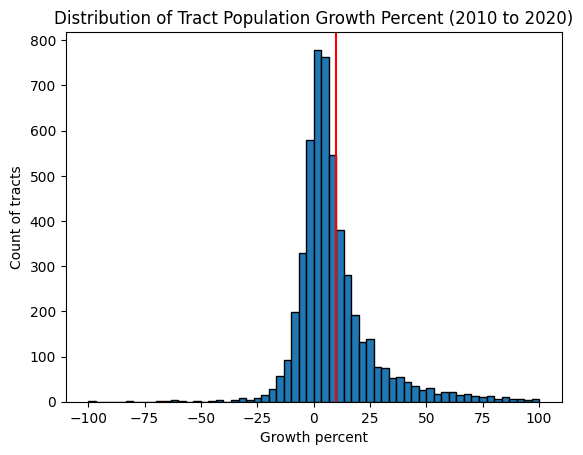

In [22]:
explore = df[df["pop_total_2010"] > 0].copy()
explore["growth_pct"] = (explore["pop_total_2020"] - explore["pop_total_2010"]) / explore["pop_total_2010"] * 100

#Histogram of growth percent. We zoom into -100 to 100 because a few tiny tracts have huge
#percentages (50 people -> 1000 people is +1900%) and they squish the plot.
plt.figure()
plt.hist(explore["growth_pct"], bins=60, range=(-100, 100), edgecolor="black")
plt.axvline(10, color="red")   #This is our 10% cutoff line
plt.title("Distribution of Tract Population Growth Percent (2010 to 2020)")
plt.xlabel("Growth percent")
plt.ylabel("Count of tracts")
plt.show()

In [23]:
# How many tracts grew and how many didn't.
explore["growth"] = (explore["growth_pct"] >= 10).astype(int)
explore["growth"].value_counts()

,count
growth,
0,3433
1,1792


In [24]:
# Same thing but just in proportion format
explore["growth"].value_counts(normalize=True)

,proportion
growth,
0,0.657033
1,0.342967


In [25]:
#Initial observation 1
explore.groupby("settlement_type")["growth"].mean()

,growth
settlement_type,
rural,0.321174
suburban,0.478792
urban,0.280218


In [26]:
#Initial observation 2
explore.groupby("STATE")["growth"].mean().sort_values()

,growth
STATE,
Wyoming,0.175573
New Mexico,0.178715
Montana,0.317343
Colorado,0.347021
Arizona,0.350658
Nevada,0.379412
Utah,0.413675
Idaho,0.436242


# Initial observations.

- About 34.29% of tracts are growth tracts and 65.70% are not, so the classes are uneven but not completely unbalanced. "No growth" is the majority class meaning this is what the model will likely predict.
- Suburban tracts grow the most (47.88%), while urban tracts grow the least (28.02%).
- By state, Idaho and Utah have the highest share of growth tracts , while Wyoming and New Mexico have the lowest.



# Phase 3: Data Preparation

# Per tract rate normalization

In [27]:
model_df = df.copy()
# DISCLAIMER: AI Assisted code build to ensure correct format.

#Housing
model_df["pct_owner"]  = model_df["housing_owner_occ_2010"] / model_df["housing_occupied_2010"]
model_df["pct_vacant"] = model_df["housing_vacant_2010"] / (model_df["housing_occupied_2010"] + model_df["housing_vacant_2010"])

#Age
kids_cols    = ["age_under5_2010","age_5to9_2010","age_10to14_2010","age_15to17_2010"]
senior_cols  = ["age_65to69_2010","age_70to74_2010","age_75to79_2010","age_80to84_2010","age_85plus_2010"]
model_df["pct_kids"]    = model_df[kids_cols].sum(axis=1)    / model_df["pop_total_2010"]
model_df["pct_seniors"] = model_df[senior_cols].sum(axis=1)  / model_df["pop_total_2010"]

#Race / Hispanic
hisp_cols = ["race_hispwhite_2010","race_hispblack_2010","race_hispaian_2010",
             "race_hispapi_2010","race_hispother_2010","race_hisptwo_2010"]
model_df["pct_white"] = model_df["race_nhwhite_2010"] / model_df["pop_total_2010"]
model_df["pct_black"] = model_df["race_nhblack_2010"] / model_df["pop_total_2010"]
model_df["pct_hisp"]  = model_df[hisp_cols].sum(axis=1) / model_df["pop_total_2010"]

model_df[["pct_owner","pct_vacant","pct_kids","pct_seniors","pct_white","pct_black","pct_hisp"]].head()

,pct_owner,pct_vacant,pct_kids,pct_seniors,pct_white,pct_black,pct_hisp
1348,0.926174,0.329835,0.336502,0.114068,0.005703,0.000634,0.022180
1349,0.792353,0.289595,0.331734,0.114428,0.016347,0.000355,0.017235
1350,0.656782,0.228063,0.327155,0.094159,0.039219,0.001986,0.022505
1351,0.805760,0.325062,0.353833,0.082112,0.010562,0.000511,0.013118
1352,0.398778,0.171367,0.385536,0.075312,0.054115,0.002743,0.027431


In [28]:
#Handling the undefined calculation cases
model_df = df.copy()

model_df = model_df[model_df["pop_total_2010"] > 0]
model_df = model_df[model_df["land_area_sqkm"] > 0]
model_df = model_df[model_df["pop_total_2010"] >= 100].copy()
model_df.shape

(5215, 49)

In [29]:
#Target build with 10% cutoff
model_df["growth_pct"] = (model_df["pop_total_2020"] - model_df["pop_total_2010"]) / model_df["pop_total_2010"] * 100
model_df["growth"] = (model_df["growth_pct"] >= 10).astype(int)

model_df["growth"].value_counts()

,count
growth,
0,3428
1,1787


Class balance after cleaning: roughly 34% growth  and 66% no-growth. Not perfectly balanced, but the minority class is large enough that the model is not forced into a single-class.

In [30]:
# These are the columns we feed the model, some have NaN values.
# We first ID our numeric and categorical features, combine those into one data set, then drop the NaN values.
numeric_features = ["pct_owner","pct_vacant","pct_kids","pct_seniors",
                    "pct_white","pct_black","pct_hisp","density_perkm2"]
categorical_features = ["settlement_type","STATE"]
feature_cols = numeric_features + categorical_features

# Check if percentage columns are missing and re-calculate if necessary
if not all(col in model_df.columns for col in numeric_features):
    # Re-calculate Housing shares
    model_df["pct_owner"]  = model_df["housing_owner_occ_2010"] / model_df["housing_occupied_2010"]
    model_df["pct_vacant"] = model_df["housing_vacant_2010"] / (model_df["housing_occupied_2010"] + model_df["housing_vacant_2010"])

    # Re-calculate Age shares
    kids_cols    = ["age_under5_2010","age_5to9_2010","age_10to14_2010","age_15to17_2010"]
    senior_cols  = ["age_65to69_2010","age_70to74_2010","age_75to79_2010","age_80to84_2010","age_85plus_2010"]
    model_df["pct_kids"]    = model_df[kids_cols].sum(axis=1)    / model_df["pop_total_2010"]
    model_df["pct_seniors"] = model_df[senior_cols].sum(axis=1)  / model_df["pop_total_2010"]

    # Re-calculate Race / Hispanic shares
    hisp_cols = ["race_hispwhite_2010","race_hispblack_2010","race_hispaian_2010",
                 "race_hispapi_2010","race_hispother_2010","race_hisptwo_2010"]
    model_df["pct_white"] = model_df["race_nhwhite_2010"] / model_df["pop_total_2010"]
    model_df["pct_black"] = model_df["race_nhblack_2010"] / model_df["pop_total_2010"]
    model_df["pct_hisp"]  = model_df[hisp_cols].sum(axis=1) / model_df["pop_total_2010"]

model_df = model_df.dropna(subset=feature_cols).copy()
model_df.shape

(5204, 58)

In [31]:
# Train_Test split
from sklearn.model_selection import train_test_split

X = model_df[feature_cols]
y = model_df["growth"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Phase 4: Modeling

1. k-means clustering: we group tracts into "neighborhood types" from their composition, choosing k with an elbow plot.
2. Cluster-as-feature: we one-hot encode that cluster label and add it.
3. Two classifiers: Logistic Regression and a Random Forest.

- To avoid leakage, we fit the scaler and k-means on the training data only,
then apply them to the test data.



In [32]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

cluster_scaler = MinMaxScaler()
X_train_scaled = cluster_scaler.fit_transform(X_train[numeric_features])

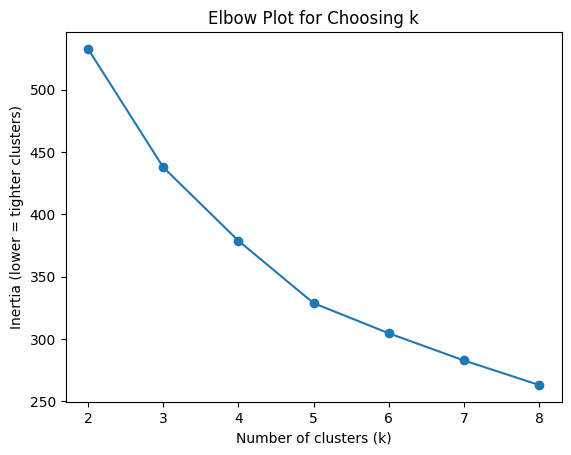

In [33]:
from sklearn.metrics import silhouette_score

k_values = range(2, 9)
inertias = []
silhouettes = []
for k in k_values:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_test.fit(X_train_scaled)
    inertias.append(km_test.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, km_test.labels_, sample_size=3000, random_state=42))

plt.figure()
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Plot for Choosing k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (lower = tighter clusters)")
plt.show()



The elbow plot drops steeply through about **k = 3 to 4** and then flattens out, so beyond k=4 extra clusters stop buying us much tighter groupings.

In [34]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

X_train = X_train.copy()
X_test = X_test.copy()
X_train["cluster"] = kmeans.predict(cluster_scaler.transform(X_train[numeric_features])).astype(str)
X_test["cluster"]  = kmeans.predict(cluster_scaler.transform(X_test[numeric_features])).astype(str)

X_train["cluster"].value_counts()

,count
cluster,
2,1798
0,839
3,739
1,527


In [35]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = cluster_scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=numeric_features)
centroids_df.index.name = "cluster"
centroids_df

,pct_owner,pct_vacant,pct_kids,pct_seniors,pct_white,pct_black,pct_hisp,density_perkm2
cluster,,,,,,,,
0,0.590149,0.127151,0.305096,0.090175,0.262525,0.056405,0.554725,1718.797657
1,0.763538,0.291511,0.159397,0.280130,0.873649,0.009472,0.078302,336.236776
2,0.780644,0.077586,0.270513,0.115054,0.779184,0.018939,0.138698,943.716339
3,0.394830,0.113638,0.195218,0.107840,0.638112,0.053468,0.213456,2104.850047


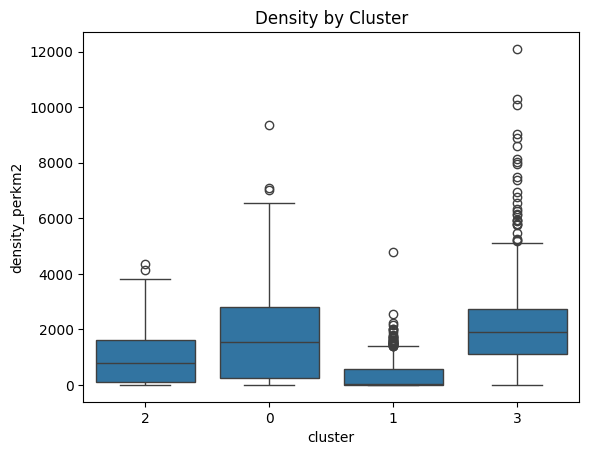

In [36]:
import seaborn as sns

profile = X_train.copy()
profile["growth"] = y_train.values
sns.boxplot(x="cluster", y="density_perkm2", data=profile)
plt.title("Density by Cluster")
plt.show()

Cluster Interpretation:
- Cluster 0: high % Hispanic, lower % white, fairly dense. Predominantly Hispanic young-family urban tracts.
- Cluster 1: very high vacancy, more seniors, very high % white, low density. Likely resort,second-home, and remote rural tracts.
- Cluster 2: high homeownership, low vacancy, mostly white, medium density. Mainly white suburban family homeowner tracts (largest cluster).
- Cluster 3: low homeownership (more renters) and the highest density. Dense urban renter tracts.


In [37]:
categorical_with_cluster = ["settlement_type", "STATE", "cluster"]

In [38]:
#Preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_with_cluster)
    ]
)

In [39]:
#Classifier 1: Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000))
])

logreg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['pct_owner', 'pct_vacant',
                                                   'pct_kids', 'pct_seniors',
                                                   'pct_white', 'pct_black',
                                                   'pct_hisp',
                                                   'density_perkm2']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['settlement_type', 'STATE',
                                                   'cluster'])])),
                ('clf', LogisticRegression(max_iter=2000))])

In [40]:
#Classifier 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

forest_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['pct_owner', 'pct_vacant',
                                                   'pct_kids', 'pct_seniors',
                                                   'pct_white', 'pct_black',
                                                   'pct_hisp',
                                                   'density_perkm2']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['settlement_type', 'STATE',
                                                   'cluster'])])),
                ('clf',
                 RandomForestClassifier(max_depth=12, min_samples_leaf=20,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

# Phase 5: Evaluation


In [41]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

### Logistic Regression results

In [42]:
logreg_pred = logreg_model.predict(X_test)
print(confusion_matrix(y_test, logreg_pred))
print(classification_report(y_test, logreg_pred, digits=3))

[[787  68]
 [306 140]]
              precision    recall  f1-score   support

           0      0.720     0.920     0.808       855
           1      0.673     0.314     0.428       446

    accuracy                          0.713      1301
   macro avg      0.697     0.617     0.618      1301
weighted avg      0.704     0.713     0.678      1301



In [43]:
#AUC
roc_auc_score(y_test, logreg_model.predict_proba(X_test)[:, 1])

np.float64(0.7186793590853067)

### Random Forest results

In [44]:
forest_pred = forest_model.predict(X_test)
print(confusion_matrix(y_test, forest_pred))
print(classification_report(y_test, forest_pred, digits=3))

[[799  56]
 [287 159]]
              precision    recall  f1-score   support

           0      0.736     0.935     0.823       855
           1      0.740     0.357     0.481       446

    accuracy                          0.736      1301
   macro avg      0.738     0.646     0.652      1301
weighted avg      0.737     0.736     0.706      1301



In [45]:
#AUC
roc_auc_score(y_test, forest_model.predict_proba(X_test)[:, 1])

np.float64(0.7767786431699577)

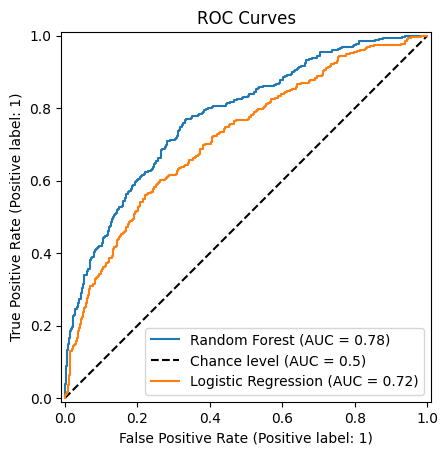

In [46]:
RocCurveDisplay.from_estimator(forest_model, X_test, y_test, name="Random Forest", plot_chance_level=True)
RocCurveDisplay.from_estimator(logreg_model, X_test, y_test, name="Logistic Regression", ax=plt.gca())
plt.title("ROC Curves")
plt.show()

### Which metric matters most?

We believe recall on the growth class matters most. The agency's whole goal is to catch the neighborhoods that are about to grow so they can fund them early. If we miss a real growth tract (FN), the agency under-builds and people show up to crowded schools and roads. If we wrongly flag a flat tract (FP), the cost is mostly some money spent in a place that stayed steady. Missing growth is worse than a false alarm.


In [47]:
forest_prob = forest_model.predict_proba(X_test)[:, 1]
forest_pred_low = (forest_prob >= 0.35).astype(int)
print(confusion_matrix(y_test, forest_pred_low))
print(classification_report(y_test, forest_pred_low, digits=3))

[[604 251]
 [128 318]]
              precision    recall  f1-score   support

           0      0.825     0.706     0.761       855
           1      0.559     0.713     0.627       446

    accuracy                          0.709      1301
   macro avg      0.692     0.710     0.694      1301
weighted avg      0.734     0.709     0.715      1301



### Feature importance (best model = Random Forest)

In [48]:
feature_names = forest_model.named_steps["preprocess"].get_feature_names_out()
importances = forest_model.named_steps["clf"].feature_importances_

importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
importance_df = importance_df.sort_values("Importance", ascending=False)
importance_df.head(10)

,Feature,Importance
3,num__pct_seniors,0.159703
7,num__density_perkm2,0.156843
1,num__pct_vacant,0.105859
2,num__pct_kids,0.105518
5,num__pct_black,0.093597
6,num__pct_hisp,0.078547
4,num__pct_white,0.073542
0,num__pct_owner,0.064381
9,cat__settlement_type_suburban,0.048292
10,cat__settlement_type_urban,0.031277


# Ablation

In [49]:
def auc_for(cat_cols, clf):
    prep = ColumnTransformer([
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])
    pipe = Pipeline([("preprocess", prep), ("clf", clf)])
    pipe.fit(X_train, y_train)
    return roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

ablation = pd.DataFrame({
    "Model": ["Logistic Regression (simple)", "Random Forest (ensemble)"],
    "AUC without cluster": [
        auc_for(["settlement_type","STATE"], LogisticRegression(max_iter=2000)),
        auc_for(["settlement_type","STATE"], RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=20, random_state=42, n_jobs=-1)),
    ],
    "AUC with cluster": [
        auc_for(["settlement_type","STATE","cluster"], LogisticRegression(max_iter=2000)),
        auc_for(["settlement_type","STATE","cluster"], RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=20, random_state=42, n_jobs=-1)),
    ],
})
ablation["Change"] = (ablation["AUC with cluster"] - ablation["AUC without cluster"]).round(3)
ablation

,Model,AUC without cluster,AUC with cluster,Change
0,Logistic Regression (simple),0.712766,0.718679,0.006
1,Random Forest (ensemble),0.780180,0.776779,-0.003


What the ablation tells us: The cluster feature helped logistic regression slightly (+0.006) but did nothing for the random forest(-0.003). This tells us the cluster is not adding new information, it is simply packaging what the random forest already finds on its own through tree splits.




##Leakage discussion

Leakage risks and how we controlled them.
- Train/test leakage: we split into train/test before fitting anything, and we fit the scaler and k-means on the training data only, then applied them to the test set. If we had scaled or clustered on all the data first, the test rows would have influenced those steps.

Did we meet the success criterion? Yes. The random forest's AUC is about 0.78, which clears our above threshhold target and is well above the 0.50 baseline, and its accuracy (0.74) beats the majority-class rate.

# Phase 6: Deployment: Forecasting 2020 to 2030


In [50]:
forecast = pd.read_csv("forecast_tracts_2020.csv")
forecast = forecast[forecast["STATE"].isin(mountain)].copy()

#Same cleaning rules as before.
forecast = forecast[forecast["pop_total_2020"] > 0]
forecast = forecast[forecast["land_area_sqkm"] > 0]
forecast = forecast[forecast["pop_total_2020"] >= 100].copy()
forecast.shape

(5215, 48)

In [51]:
#Build the SAME rate features, but from the 2020 columns this time (same names, same denominators)
kids_2020   = ["age_under5_2020","age_5to9_2020","age_10to14_2020","age_15to17_2020"]
senior_2020 = ["age_65to69_2020","age_70to74_2020","age_75to79_2020","age_80to84_2020","age_85plus_2020"]
hisp_2020   = ["race_hispwhite_2020","race_hispblack_2020","race_hispaian_2020",
               "race_hispapi_2020","race_hispother_2020","race_hisptwo_2020"]

forecast["pct_owner"]   = forecast["housing_owner_occ_2020"] / forecast["housing_occupied_2020"]
forecast["pct_vacant"]  = forecast["housing_vacant_2020"] / (forecast["housing_occupied_2020"] + forecast["housing_vacant_2020"])
forecast["pct_kids"]    = forecast[kids_2020].sum(axis=1)   / forecast["pop_total_2020"]
forecast["pct_seniors"] = forecast[senior_2020].sum(axis=1) / forecast["pop_total_2020"]
forecast["pct_white"]   = forecast["race_nhwhite_2020"] / forecast["pop_total_2020"]
forecast["pct_black"]   = forecast["race_nhblack_2020"] / forecast["pop_total_2020"]
forecast["pct_hisp"]    = forecast[hisp_2020].sum(axis=1) / forecast["pop_total_2020"]

forecast = forecast.dropna(subset=feature_cols).copy()
forecast["cluster"] = kmeans.predict(cluster_scaler.transform(forecast[numeric_features])).astype(str)
forecast.shape

(5207, 56)

In [52]:
#Growth Prediction
forecast["pred_growth"] = forest_model.predict(forecast[feature_cols + ["cluster"]])
forecast["pred_growth"].value_counts()

,count
pred_growth,
0,4823
1,384


In [53]:
#By state growth predictions
by_state = forecast.groupby("STATE")["pred_growth"].agg(["sum","count","mean"])
by_state.columns = ["predicted_growth_tracts", "total_tracts", "share_growth"]
by_state = by_state.sort_values("share_growth", ascending=False)
by_state.round(3)

,predicted_growth_tracts,total_tracts,share_growth
STATE,,,
Utah,119,585,0.203
Idaho,28,297,0.094
Colorado,87,1237,0.070
Arizona,105,1512,0.069
Nevada,33,679,0.049
Wyoming,5,131,0.038
Montana,3,268,0.011
New Mexico,4,498,0.008


## Recommendation to the Department of Economic Development

Which states show the most predicted growth?
- Based on the 2020 to 2030 forecast, Utah stands out with by far the highest share of tracts predicted to grow, followed by Idaho. Colorado and Arizona are right in the middle of the pack, and Montana and New Mexico are at the bottom. From a budgeting standpoint, efforts for new schools, roads, and housing should focus on Utah and Idaho first.

Primary drivers?
- From the feature importance, the model leans most on a tract's age structure (% seniors, % kids) and how built-up and how empty it is (density, vacancy), with suburban location adding a further bump. Younger, growing-family, suburban neighborhoods are the most likely to keep gaining people, while older, very-high-vacancy (resort and second-home) and dense urban-core tracts are less likely to.

Model utilization and limits?
- It is a useful early-warning screen. If provided past tract data, it flags which neighborhoods look poised to grow and ranks them by state for funding considerations. However, it is limited since it only predicts on a yes or no in terms of if a state's tracts will grow, but doesn't tell you how many people.It's recall is modest at best, which is why we ran it at a lower threshold and it learned its pattern from a single decade, so it can possible miss trends and patterns from previous decades or older data.


In [54]:
import pickle

pipeline_bundle = {
    "cluster_scaler": cluster_scaler,   # your MinMaxScaler
    "kmeans": kmeans,                   # your fitted KMeans (k=4)
    "forest_model": forest_model,       # your full sklearn Pipeline (preprocessor + RF)
    "numeric_features": numeric_features,
    "feature_cols": feature_cols,
}

with open("pipeline_bundle.pkl", "wb") as f:
    pickle.dump(pipeline_bundle, f)

In [57]:
!pip install streamlit
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# ── Load pipeline ──────────────────────────────────────────────────────────────
@st.cache_resource
def load_pipeline():
    with open("pipeline_bundle.pkl", "rb") as f:
        return pickle.load(f)

bundle = load_pipeline()
cluster_scaler = bundle["cluster_scaler"]
kmeans          = bundle["kmeans"]
forest_model    = bundle["forest_model"]
numeric_features = bundle["numeric_features"]
feature_cols     = bundle["feature_cols"]

MOUNTAIN_STATES = ["Arizona","Colorado","Idaho","Montana","Nevada","New Mexico","Utah","Wyoming"]

# ── UI ─────────────────────────────────────────────────────────────────────────
st.title("🏔️ Mountain Region Neighborhood Growth Predictor")
st.markdown("Enter a census tract's 2020 characteristics to forecast whether it will gain ≥10% population by 2030.")

st.header("Tract Characteristics")

col1, col2 = st.columns(2)

with col1:
    pct_owner   = st.slider("% Owner-Occupied Housing",  0.0, 1.0, 0.65, 0.01)
    pct_vacant  = st.slider("% Vacant Units",            0.0, 1.0, 0.10, 0.01)
    pct_kids    = st.slider("% Children (age <18)",      0.0, 1.0, 0.25, 0.01)
    pct_seniors = st.slider("% Seniors (age 65+)",       0.0, 1.0, 0.15, 0.01)
    density     = st.number_input("Population Density (per km²)", min_value=0.0, value=500.0, step=10.0)

with col2:
    pct_white = st.slider("% White (non-Hispanic)", 0.0, 1.0, 0.70, 0.01)
    pct_black = st.slider("% Black (non-Hispanic)", 0.0, 1.0, 0.05, 0.01)
    pct_hisp  = st.slider("% Hispanic",             0.0, 1.0, 0.15, 0.01)
    state     = st.selectbox("State", MOUNTAIN_STATES)
    stype     = st.selectbox("Settlement Type", ["rural", "suburban", "urban"])

# ── Predict ────────────────────────────────────────────────────────────────────
if st.button("Predict Growth", type="primary"):
    numeric_vals = [pct_owner, pct_vacant, pct_kids, pct_seniors,
                    pct_white, pct_black, pct_hisp, density]

    # Assign cluster using the frozen scaler + kmeans
    scaled = cluster_scaler.transform([numeric_vals])
    cluster_label = str(kmeans.predict(scaled)[0])

    # Build the feature row
    row = dict(zip(numeric_features, numeric_vals))
    row["settlement_type"] = stype
    row["STATE"]           = state
    row["cluster"]         = cluster_label

    X_input = pd.DataFrame([row])[feature_cols + ["cluster"]]

    prob  = forest_model.predict_proba(X_input)[0][1]
    pred  = forest_model.predict(X_input)[0]

    st.divider()

    if pred == 1:
        st.success(f"✅ **Predicted to GROW** (≥10% population gain by 2030)")
    else:
        st.warning(f"⚠️ **Predicted NOT to grow** significantly by 2030")

    st.metric("Growth Probability", f"{prob:.1%}")
    st.metric("Assigned Cluster", f"Cluster {cluster_label}")

    cluster_names = {
        "0": "Hispanic Urban Family",
        "1": "Resort / Remote Rural",
        "2": "Suburban Family Homeowner",
        "3": "Dense Urban Renter"
    }
    st.caption(f"Cluster type: {cluster_names.get(cluster_label, 'Unknown')}")

    st.divider()
    st.info("**Note:** This model was trained on 2010 census data to predict 2010–2020 growth. "
            "The 2030 forecast assumes that structural relationships from the 2010s still hold.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 95.7 MB/s eta 0:00:00


2026-06-24 23:45:23.378 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 23:45:23.390 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 23:45:23.591 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-24 23:45:23.594 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 23:45:23.595 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 23:45:23.598 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 23:45:23.600 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [58]:
%%writefile app.py
!pip install streamlit
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# ── Load pipeline ──────────────────────────────────────────────────────────────
@st.cache_resource
def load_pipeline():
    with open("pipeline_bundle.pkl", "rb") as f:
        return pickle.load(f)

bundle = load_pipeline()
cluster_scaler = bundle["cluster_scaler"]
kmeans          = bundle["kmeans"]
forest_model    = bundle["forest_model"]
numeric_features = bundle["numeric_features"]
feature_cols     = bundle["feature_cols"]

MOUNTAIN_STATES = ["Arizona","Colorado","Idaho","Montana","Nevada","New Mexico","Utah","Wyoming"]

# ── UI ─────────────────────────────────────────────────────────────────────────
st.title("🏔️ Mountain Region Neighborhood Growth Predictor")
st.markdown("Enter a census tract's 2020 characteristics to forecast whether it will gain ≥10% population by 2030.")

st.header("Tract Characteristics")

col1, col2 = st.columns(2)

with col1:
    pct_owner   = st.slider("% Owner-Occupied Housing",  0.0, 1.0, 0.65, 0.01)
    pct_vacant  = st.slider("% Vacant Units",            0.0, 1.0, 0.10, 0.01)
    pct_kids    = st.slider("% Children (age <18)",      0.0, 1.0, 0.25, 0.01)
    pct_seniors = st.slider("% Seniors (age 65+)",       0.0, 1.0, 0.15, 0.01)
    density     = st.number_input("Population Density (per km²)", min_value=0.0, value=500.0, step=10.0)

with col2:
    pct_white = st.slider("% White (non-Hispanic)", 0.0, 1.0, 0.70, 0.01)
    pct_black = st.slider("% Black (non-Hispanic)", 0.0, 1.0, 0.05, 0.01)
    pct_hisp  = st.slider("% Hispanic",             0.0, 1.0, 0.15, 0.01)
    state     = st.selectbox("State", MOUNTAIN_STATES)
    stype     = st.selectbox("Settlement Type", ["rural", "suburban", "urban"])

# ── Predict ────────────────────────────────────────────────────────────────────
if st.button("Predict Growth", type="primary"):
    numeric_vals = [pct_owner, pct_vacant, pct_kids, pct_seniors,
                    pct_white, pct_black, pct_hisp, density]

    # Assign cluster using the frozen scaler + kmeans
    scaled = cluster_scaler.transform([numeric_vals])
    cluster_label = str(kmeans.predict(scaled)[0])

    # Build the feature row
    row = dict(zip(numeric_features, numeric_vals))
    row["settlement_type"] = stype
    row["STATE"]           = state
    row["cluster"]         = cluster_label

    X_input = pd.DataFrame([row])[feature_cols + ["cluster"]]

    prob  = forest_model.predict_proba(X_input)[0][1]
    pred  = forest_model.predict(X_input)[0]

    st.divider()

    if pred == 1:
        st.success(f"✅ **Predicted to GROW** (≥10% population gain by 2030)")
    else:
        st.warning(f"⚠️ **Predicted NOT to grow** significantly by 2030")

    st.metric("Growth Probability", f"{prob:.1%}")
    st.metric("Assigned Cluster", f"Cluster {cluster_label}")

    cluster_names = {
        "0": "Hispanic Urban Family",
        "1": "Resort / Remote Rural",
        "2": "Suburban Family Homeowner",
        "3": "Dense Urban Renter"
    }
    st.caption(f"Cluster type: {cluster_names.get(cluster_label, 'Unknown')}")

    st.divider()
    st.info("**Note:** This model was trained on 2010 census data to predict 2010–2020 growth. "
            "The 2030 forecast assumes that structural relationships from the 2010s still hold.")

Writing app.py


Now that the Streamlit app is saved to `app.py`, you can run it using the following steps:

1.  **Install `ngrok` (if you haven't already):** This will create a secure tunnel to expose your local Streamlit app to the internet.
2.  **Start `ngrok` and Streamlit:** Run the commands below in a new cell.

In [59]:
!pip install ngrok
!nohup streamlit run app.py &>/dev/null&

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 54.5 MB/s eta 0:00:00


In [61]:
# Download and install ngrok if it's not already there
!wget -q -c -nc https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
!unzip -qq -n ngrok-stable-linux-amd64.zip

# Run ngrok to expose port 8501 (Streamlit's default port)
get_ipython().system_raw('./ngrok tcp 8501 &')

# Get the public URL
!curl -s http://localhost:4040/api/tunnels | python3 -c \
    "import sys, json; print(json.load(sys.stdin)['tunnels'][0]['public_url'])"

/bin/bash: line 1: /usr/local/bin/ngrok: No such file or directory
